# Database

## Load the dataset

In [1]:
import pynvml
pynvml.nvmlInit()
pynvml.nvmlDeviceGetName(pynvml.nvmlDeviceGetHandleByIndex(0))
mem = pynvml.nvmlDeviceGetMemoryInfo(pynvml.nvmlDeviceGetHandleByIndex(0))
mem = mem.total/1e9
if mem < 24:
    !wget https://storage.googleapis.com/rapidsai/polars-demo/transactions-t4-20.parquet -O transactions.parquet
else:
    !wget https://storage.googleapis.com/rapidsai/polars-demo/transactions.parquet -O transactions.parquet

--2025-10-08 14:58:23--  https://storage.googleapis.com/rapidsai/polars-demo/transactions.parquet
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.46.187, 142.251.46.219, 142.250.189.187, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.46.187|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4274457161 (4.0G) [application/octet-stream]
Saving to: ‘transactions.parquet’

transactions.parque 100%[===================>]   3.98G  12.6MB/s    in 4m 34s  

2025-10-08 15:02:57 (14.9 MB/s) - ‘transactions.parquet’ saved [4274457161/4274457161]



## Create DuckDB database

In [72]:
import duckdb

# Paths
db_path = 'transactions.duckdb'
parquet_path = 'transactions.parquet'

# Connect to DuckDB
conn = duckdb.connect(db_path)

# Load Parquet directly into a table
conn.execute(f"""
CREATE OR REPLACE TABLE trxns AS 
SELECT * FROM read_parquet('{parquet_path}');
""")

# GPU Polars (for data manipulations)

Pull the data from the DuckDB database

In [73]:
import polars as pl

pl_trxns = pl.from_arrow(
    duckdb.connect("transactions.duckdb")
           .execute("SELECT * FROM trxns")
           .arrow()
).lazy()

Observe the first 5 rows of the data

In [74]:
(
    pl_trxns
    .head()
    .collect(engine = "gpu")
)

CUST_ID,START_DATE,END_DATE,TRANS_ID,DATE,YEAR,MONTH,DAY,EXP_TYPE,AMOUNT
str,date,date,str,date,i64,i64,i64,str,f64
"""CI6XLYUMQK""",2015-05-01,null,"""T8I9ZB5A6X90UG8""",2015-09-11,2015,9,11,"""Motor/Travel""",20.27
"""CI6XLYUMQK""",2015-05-01,null,"""TZ4JSLS7SC7FO9H""",2017-02-08,2017,2,8,"""Motor/Travel""",12.85
"""CI6XLYUMQK""",2015-05-01,null,"""TTUKRDDJ6B6F42H""",2015-08-01,2015,8,1,"""Housing""",383.8
"""CI6XLYUMQK""",2015-05-01,null,"""TDUHFRUKGPPI6HD""",2019-03-16,2019,3,16,"""Entertainment""",5.72
"""CI6XLYUMQK""",2015-05-01,null,"""T0JBZHBMSVRFMMD""",2015-05-15,2015,5,15,"""Entertainment""",11.06


Filter and group transactions by year, month, and type, then compute total, average, and count of amounts, returning only high-value groups

In [75]:
%%time

filtered_df = (
    pl_trxns
    .filter(
        (pl.col("YEAR").is_in([2015, 2017, 2019])) &
        (pl.col("EXP_TYPE").is_in(["Motor/Travel", "Entertainment", "Housing"])) &
        (pl.col("AMOUNT") > 10)
    )
)

result = (
    filtered_df
    .group_by(["YEAR", "MONTH", "EXP_TYPE"])
    .agg([
        pl.len().alias("num_transcations"),
        pl.sum("AMOUNT").alias("total_amount"),
        pl.mean("AMOUNT").alias("avg_amount")
    ])
    .filter(pl.col("total_amount") > 50)
    .sort(["total_amount", "avg_amount"], descending = [True, True])
    .collect(engine = "gpu")
)

CPU times: user 1min 14s, sys: 4.95 s, total: 1min 19s
Wall time: 1min 15s


Save the result back to DuckDB database

In [76]:
conn.execute("CREATE OR REPLACE TABLE result AS SELECT * FROM result")

In [77]:
result

YEAR,MONTH,EXP_TYPE,num_transcations,total_amount,avg_amount
i64,i64,str,u32,f64,f64
2019,12,"""Motor/Travel""",313763,8.3668e7,266.660524
2019,11,"""Motor/Travel""",314195,7.6235e7,242.636919
2019,10,"""Motor/Travel""",310862,6.8135e7,219.181247
2019,9,"""Motor/Travel""",308298,6.1398e7,199.15254
2019,8,"""Motor/Travel""",307260,6.0403e7,196.58526
…,…,…,…,…,…
2015,3,"""Motor/Travel""",226626,2.1418e7,94.506841
2015,2,"""Housing""",14657,2.1170e7,1444.331609
2015,1,"""Housing""",14517,2.0897e7,1439.518141


In [78]:
type(result)

polars.dataframe.frame.DataFrame

In [8]:
conn.close()

# cuDF (for feature engineering)

In [79]:
%load_ext cudf.pandas

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [80]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [115]:
df = pd.DataFrame(result.to_pandas())

In [116]:
df.columns = [col.lower() for col in df.columns]

In [117]:
df.head()

,year,month,exp_type,num_transcations,total_amount,avg_amount
0,2019,12,Motor/Travel,313763,83668206.04,266.660524
1,2019,11,Motor/Travel,314195,76235306.88,242.636919
2,2019,10,Motor/Travel,310862,68135120.88,219.181247
3,2019,9,Motor/Travel,308298,61398329.63,199.152540
4,2019,8,Motor/Travel,307260,60402786.90,196.585260


In [118]:
df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   year              108 non-null    int64
 1   month             108 non-null    int64
 2   exp_type          108 non-null    object
 3   num_transcations  108 non-null    uint32
 4   total_amount      108 non-null    float64
 5   avg_amount        108 non-null    float64
dtypes: float64(2), int64(2), object(1), uint32(1)
memory usage: 5.3+ KB


In [119]:
df['num_transcations'] = df['num_transcations'].astype('float32')

In [120]:
df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   year              108 non-null    int64
 1   month             108 non-null    int64
 2   exp_type          108 non-null    object
 3   num_transcations  108 non-null    float32
 4   total_amount      108 non-null    float64
 5   avg_amount        108 non-null    float64
dtypes: float32(1), float64(2), int64(2), object(1)
memory usage: 5.3+ KB


In [121]:
numeric_columns = []
categorical_columns = []

for column in df.columns:
    if df[column].dtype in ['int64', 'float64', 'int32', 'float32']:
        numeric_columns.append(column)
    else:
        categorical_columns.append(column)

build a fresh, unfitted preprocessor pipeline

In [124]:
def to_float32(X):
    """Convert to float32 to save memory."""
    return X.astype(np.float32)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('float32', FunctionTransformer(to_float32, accept_sparse=False)),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore',
                             sparse_output=False,
                             dtype=np.float32)),
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_columns),
    ('categorical', categorical_pipeline, categorical_columns),
], sparse_threshold=0.0, verbose_feature_names_out=True)

preprocessor.set_output(transform="pandas")
df_result = preprocessor.fit_transform(df)


column rename

In [151]:
for i in range(5):
    df_result = df_result.rename(columns = {df_result.columns[i]: numeric_columns[i]})

In [153]:
df_result.columns = [c.replace("categorical__x0", "exp_type").lower() for c in df_result.columns]    

# cuML (for GPU-accelerated clustering)

In [156]:
df_result.head()

,year,month,num_transcations,total_amount,avg_amount,exp_type_entertainment,exp_type_housing,exp_type_motor/travel
0,1.224745,1.593255,-0.216192,4.042043,-0.461406,0.0,0.0,1.0
1,1.224745,1.303572,-0.215020,3.430902,-0.494699,0.0,0.0,1.0
2,1.224745,1.013890,-0.224057,2.764896,-0.527205,0.0,0.0,1.0
3,1.224745,0.724207,-0.231008,2.210990,-0.554962,0.0,0.0,1.0
4,1.224745,0.434524,-0.233823,2.129136,-0.558520,0.0,0.0,1.0


## KMeans

In [157]:
%load_ext cuml.accel

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [158]:
from sklearn.cluster import KMeans, DBSCAN
from hdbscan import HDBSCAN
from umap import UMAP

elbow method to determine the optimal number of clusters

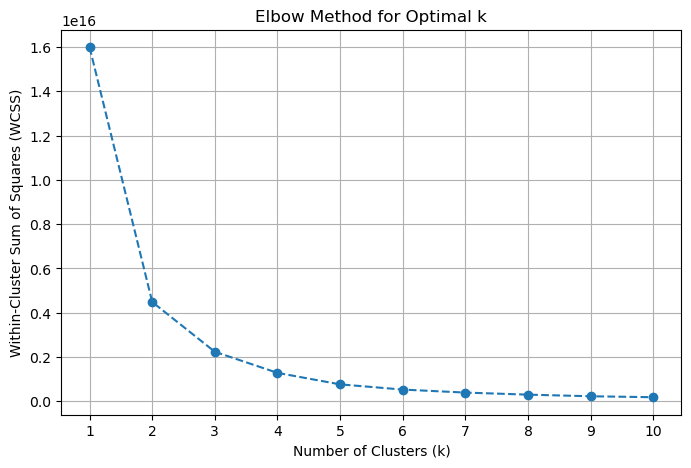

CPU times: user 563 ms, sys: 80.3 ms, total: 644 ms
Wall time: 593 ms


In [159]:
%%time

import matplotlib.pyplot as plt

# Define range of clusters to test
cluster_range = range(1, 11)
wcss = []

# Loop through different cluster numbers
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(df[['total_amount', 'num_transcations']])
    wcss.append(kmeans.inertia_)

# Plot WSSE vs. Number of Clusters
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

plug in the optimal number of clusters = 5, and create the visualization

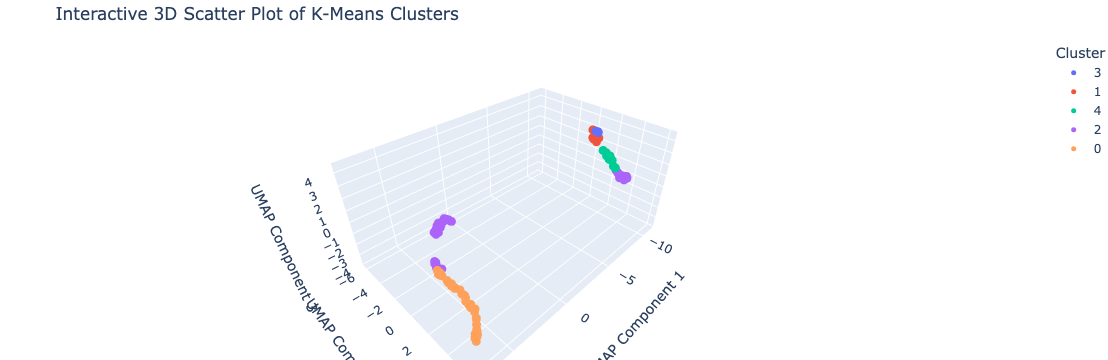

In [162]:
import plotly.express as px
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from hdbscan import HDBSCAN
from sklearn.mixture import GaussianMixture
from umap import UMAP

n_clusters = 5
random_state = 42
n_init = 10

# Step 1: Perform K-Means Clustering using cuML
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)
kmeans.fit(df[['total_amount', 'num_transcations']])

cluster_labels = kmeans.labels_

# Step 2: Reduce Dimensionality to 3D using cuML UMAP
umap_3d = UMAP(n_neighbors=15, min_dist=0.1, n_components=3)
embedding_3d = umap_3d.fit_transform(df[['total_amount', 'num_transcations']])

# Convert GPU arrays back to NumPy for Plotly
import cupy as cp
embedding_3d_cpu = cp.asnumpy(embedding_3d)
cluster_labels_cpu = cp.asnumpy(cluster_labels)

# Step 3: Create Interactive 3D Scatter Plot using Plotly
fig = px.scatter_3d(
    x=embedding_3d_cpu[:, 0],
    y=embedding_3d_cpu[:, 1],
    z=embedding_3d_cpu[:, 2],
    color=cluster_labels_cpu.astype(str),  # Convert labels to string for coloring
    title="Interactive 3D Scatter Plot of K-Means Clusters",
    labels={"color": "Cluster"}
)

# Customize the plot
fig.update_traces(marker=dict(size=5))  # Adjust marker size
fig.update_layout(
    scene=dict(
        xaxis_title="UMAP Component 1",
        yaxis_title="UMAP Component 2",
        zaxis_title="UMAP Component 3",
    ),
    margin=dict(l=0, r=0, b=0, t=40),  # Reduce margins for a cleaner look
)

# Show the plot
fig.show()

## DBSCAN
Use grid search + silhouette score to determine the best value of epsilon

In [163]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Standardize the features before clustering
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['total_amount', 'num_transcations']])

# Define parameters
min_samples = 5
eps_values = cp.linspace(0.05, 2.05, 10)
silhouette_scores = []

for eps in eps_values:
    clusterer = DBSCAN(eps=float(eps), min_samples=min_samples)
    labels = clusterer.fit_predict(scaled_features)

    # Count clusters (excluding noise label -1)
    unique_labels = cp.unique(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    # Only compute silhouette score if ≥2 valid clusters
    if n_clusters > 1:
        score = silhouette_score(scaled_features, cp.asnumpy(labels))
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(cp.nan)  # mark invalid cases


In [164]:
silhouette_scores

[0.1405808318026981,
 0.6161968000364387,
 0.5441610581867067,
 0.5101804124536229,
 0.5101804124536229,
 0.5101804124536229,
 nan,
 nan,
 nan,
 nan]

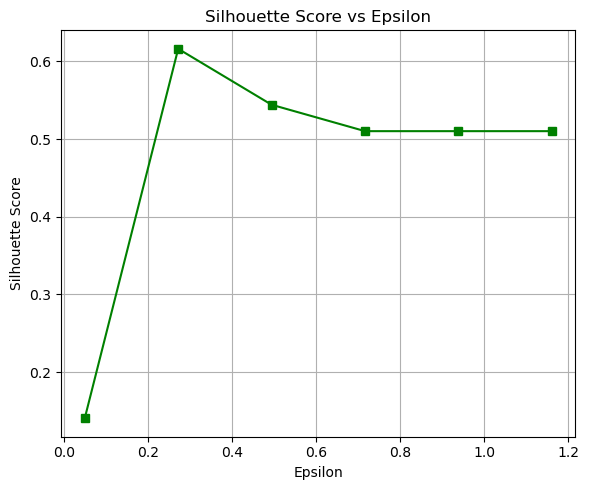

In [165]:
# --- Plot Results ---
plt.figure(figsize=(6, 5))
plt.plot(cp.asnumpy(eps_values), silhouette_scores, marker='s', linestyle='-', color='g')
plt.xlabel('Epsilon')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Epsilon')
plt.grid(True)
plt.tight_layout()
plt.show()


[2025-10-08 17:32:45.498] [CUML] [info] build_algo set to brute_force_knn because random_state is given


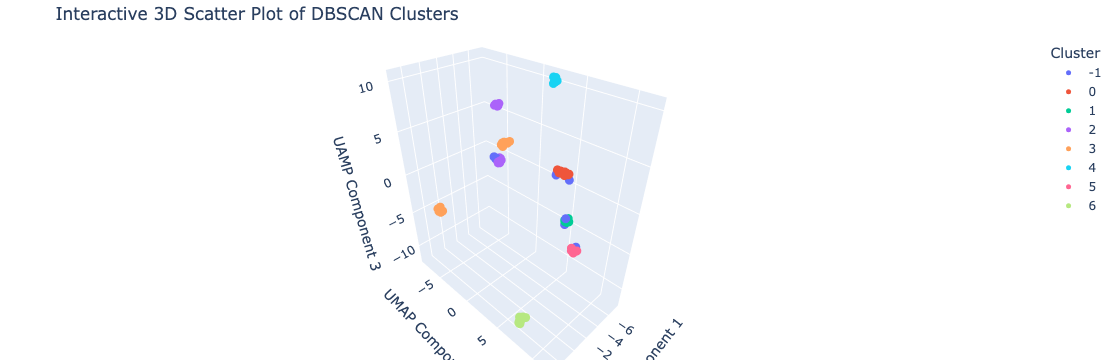

In [166]:

# Step 2: Perform DBSCAN clustering on the GPU
dbscan_model = DBSCAN(eps=0.25, min_samples=5)
dbscan_model.fit(scaled_features)

# Step 3: reduce Dimensionality to 3D using cuML UMAP
umap_3d = UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
embedding_3d = umap_3d.fit_transform(scaled_features)

# Convert the cluster labels from a CuPy array back to a NumPy array for printing
embedding_3d_cpu = cp.asnumpy(embedding_3d)
labels_cpu = cp.asnumpy(dbscan_model.labels_)

# Step 4: Create interactive 3D scatter plot using Plotly
fig = px.scatter_3d(
    x = embedding_3d_cpu[:, 0],
    y = embedding_3d_cpu[:, 1],
    z = embedding_3d_cpu[:, 2],
    color = labels_cpu.astype(str),
    title = "Interactive 3D Scatter Plot of DBSCAN Clusters",
    labels = {"color": "Cluster"}
)

# Customize the plot
fig.update_traces(marker = dict(size = 5))
fig.update_layout(
    scene = dict(
        xaxis_title = "UMAP Component 1",
        yaxis_title = "UMAP Component 2",
        zaxis_title = "UAMP Component 3",
    ),
    margin = dict(l=0, r=0, b=0, t=40),
)

# Show the plot
fig.show()

## HDBSCAN
Use grid search + persistence score + silhouette score to identify the optimal min_cluster_size

In [171]:
# Try different `min_cluster_size` values
min_cluster_sizes = range(100, 1000, 5)
persistence_scores = []
silhouette_scores = []

for size in min_cluster_sizes:
    clusterer = HDBSCAN(min_cluster_size=size)
    clusterer.fit(scaled_features)
    p = clusterer.cluster_persistence_
    persistence_scores.append(cp.mean(p).item())  # Measures cluster validity

    labels = clusterer.labels_
    s = silhouette_score(scaled_features, labels)
    silhouette_scores.append(s)

# --- Plot Results ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Persistence Score Plot
axes[0].plot(min_cluster_sizes, persistence_scores, marker='o', linestyle='--', color='b')
axes[0].set_xlabel('min_cluster_size')
axes[0].set_ylabel('Cluster Persistence Score')
axes[0].set_title('Optimal min_cluster_size based on Persistence Score')
axes[0].grid(True)

# Silhouette Score Plot
axes[1].plot(min_cluster_sizes, silhouette_scores, marker='s', linestyle='-', color='g')
axes[1].set_xlabel('min_cluster_size')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Optimal min_cluster_size based on Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

/home/allisond/miniconda/envs/rapids-25.10/lib/python3.11/site-packages/cupy/_statistics/meanvar.py:162: RuntimeWarning:

Mean of empty slice.

/home/allisond/miniconda/envs/rapids-25.10/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning:

invalid value encountered in divide



ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)